**About the dataset (Appliances Energy Prediction data)**

Appliances: Energy use in Wh (Target Variable)
lights: Energy use of light fixtures in the house in Wh

1. T1: Temperature in the kitchen area in Celsius
2. RH_1: Humidity in the kitchen area in %
3. T2: Temperature in the living room area in Celsius
4. RH_2: Humidity in the living room area in %
5. T3: Temperature in the laundry room area
6. RH_3: Humidity in the laundry room area in %
7. T4: Temperature in the office room in Celsius
8. RH_4: Humidity in the office room in %
9. T5: Temperature in the bathroom in Celsius
10. RH_5: Humidity in the bathroom in %
11. T6: Temperature outside the building (north side) in Celsius
12. RH_6: Humidity outside the building (north side) in %
13. T7: Temperature in ironing room in Celsius
14. RH_7: Humidity in ironing room in %
15. T8: Temperature in teenager room 2 in Celsius
16. RH_8: Humidity in teenager room 2 in %
17. T9: Temperature in parents room in Celsius
18. RH_9: Humidity in parents room in %
19. T_out: Temperature outside the building in Celsius
20. Pres_mm_hg: Pressure in mm Hg
21. RH_out: Humidity outside the building in %
22. Windspeed: Speed of the wind in m/s
23. Visibility: Visibility of the building from the nearest weather station in km

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = [15, 6]
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

In [2]:
df_energy=pd.read_csv("energy_data.csv")
df_energy.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility
0,60,20,20.700000,44.700000,19.500000,45.590000,21.390000,41.95,20.566667,45.626667,...,43.290000,20.500000,52.790000,18.306667,47.590000,11.016667,756.533333,88.333333,8.833333,38.166667
1,60,0,21.290000,37.863333,19.390000,39.663333,21.790000,36.70,20.463333,37.526667,...,32.095000,22.000000,39.223333,19.600000,38.826667,8.350000,761.800000,70.000000,3.500000,40.000000
2,80,0,21.390000,35.790000,19.290000,37.700000,22.760000,34.29,21.323333,34.730000,...,29.200000,22.390000,37.290000,19.463333,35.500000,6.866667,762.333333,69.666667,3.000000,35.666667
3,40,0,19.033333,41.826667,18.533333,41.290000,18.100000,43.79,15.890000,47.530000,...,40.138889,19.594444,51.062778,15.100000,46.760000,5.133333,769.583333,92.000000,4.833333,23.166667
4,60,30,21.700000,46.633333,20.700000,45.900000,22.323333,44.79,21.000000,47.966667,...,45.200000,20.469444,53.189444,18.290000,51.863333,8.633333,757.566667,95.666667,6.000000,55.333333


# Objective

1. Understand some intricacies of EDA. How to deal with Clumsy and large number of columns in the dataset.
2. Transformation
3. Encoding
4. Feature Selection - focus on Forward and Backward Selection.
5. Recursive Feature Selection.
6. Cross Validation.
7. Bias and Variance Concepts
8. Regularization.
9. Grid Search CV

### Check the attributes of the Dataset

In [ ]:
df_energy.shape

(1000, 25)

In [ ]:
df_energy.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,94.580000,3.880000,21.689083,40.220658,20.308276,40.456847,22.291003,39.193848,20.877548,38.883203,...,35.202685,22.110523,42.876733,19.500280,41.421305,7.270235,755.522126,79.722845,4.057964,38.219167
std,95.963705,8.075321,1.533835,3.966141,2.123854,4.080899,1.939537,3.171917,1.947205,4.297529,...,5.069127,1.877895,5.208331,1.926965,4.132533,5.207305,7.433976,14.623087,2.454295,11.679127
min,20.000000,0.000000,16.823333,28.193333,16.200000,24.823333,17.290000,33.200000,15.160000,29.421429,...,23.290000,16.583333,29.600000,15.000000,29.426667,-4.955556,730.700000,24.500000,0.000000,3.333333
25%,50.000000,0.000000,20.790000,37.200000,18.790000,38.057500,20.823333,36.900000,19.566667,35.484167,...,31.352738,20.910625,39.200000,18.100000,38.421429,3.537500,750.800000,70.000000,2.000000,28.666667
50%,60.000000,0.000000,21.600000,39.700000,19.890000,40.400000,22.100000,38.500000,20.760000,38.290000,...,34.609111,22.200000,42.352333,19.500000,40.566667,6.841667,755.941667,83.833333,3.666667,40.000000
75%,100.000000,0.000000,22.533333,42.861667,21.390000,43.200000,23.390000,41.500000,22.100000,41.992500,...,39.000000,23.441857,46.430694,20.600000,44.308333,10.433333,760.937500,91.333333,5.666667,40.000000
max,800.000000,40.000000,26.066667,54.800000,29.100000,53.249880,28.867143,49.930000,26.100000,50.963333,...,49.444444,27.100000,56.598333,24.434000,52.700000,25.600000,772.200000,100.000000,13.000000,65.000000


In [ ]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   1000 non-null   int64  
 1   lights       1000 non-null   int64  
 2   T1           1000 non-null   float64
 3   RH_1         1000 non-null   float64
 4   T2           1000 non-null   float64
 5   RH_2         1000 non-null   float64
 6   T3           1000 non-null   float64
 7   RH_3         1000 non-null   float64
 8   T4           1000 non-null   float64
 9   RH_4         1000 non-null   float64
 10  T5           1000 non-null   float64
 11  RH_5         1000 non-null   float64
 12  T6           1000 non-null   float64
 13  RH_6         1000 non-null   float64
 14  T7           1000 non-null   float64
 15  RH_7         1000 non-null   float64
 16  T8           1000 non-null   float64
 17  RH_8         1000 non-null   float64
 18  T9           1000 non-null   float64
 19  RH_9   

In [ ]:
# to know the percent of missing values
(df_energy.isnull().sum() /df_energy.index.size) *100 

Appliances     0.0
lights         0.0
T1             0.0
RH_1           0.0
T2             0.0
RH_2           0.0
T3             0.0
RH_3           0.0
T4             0.0
RH_4           0.0
T5             0.0
RH_5           0.0
T6             0.0
RH_6           0.0
T7             0.0
RH_7           0.0
T8             0.0
RH_8           0.0
T9             0.0
RH_9           0.0
T_out          0.0
Press_mm_hg    0.0
RH_out         0.0
Windspeed      0.0
Visibility     0.0
dtype: float64

### Prodecure for solving the problem

1. Univariate Analysis.
2. Outlier Treatment.
3. Missing Value Treatment.
4. Univariate.
5. Bivariate.
6. Multivariate.
7. Feature Engineering.
8. Scaling and Transformation.

### Modeling

1. Split the Data into Train and Test.
2. Build the Model- Linear Regression.
3. Evaluate the performance - r2 , RMSE.
4. Underfitting vs Overfitting (Bias vs Variance).
5. Assumption of the Model.
7. Cross validation Approach and Feature Selection.
6. If Assumptions fail - then apply Decision Tree, Random Forest, Bagging, Boosting models are build.

**Remove Any Insignificant Variables**

**At the outset we do not have any insignificant variables**

### Numerical and Categorical variables

In [ ]:
cols=list(df_energy.select_dtypes(include=np.number).columns)
cols

['Appliances',
 'lights',
 'T1',
 'RH_1',
 'T2',
 'RH_2',
 'T3',
 'RH_3',
 'T4',
 'RH_4',
 'T5',
 'RH_5',
 'T6',
 'RH_6',
 'T7',
 'RH_7',
 'T8',
 'RH_8',
 'T9',
 'RH_9',
 'T_out',
 'Press_mm_hg',
 'RH_out',
 'Windspeed',
 'Visibility']

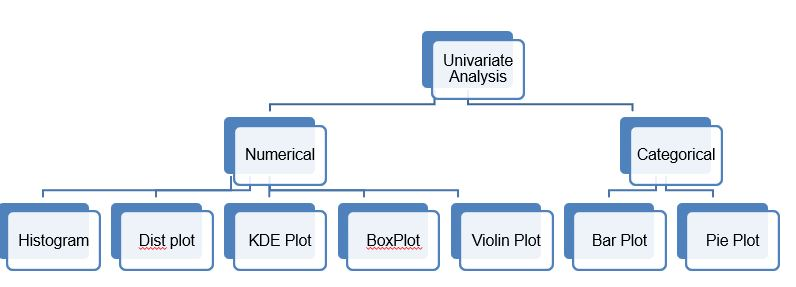

In [ ]:
from IPython.display import Image
Image(filename='Univariate.JPG',width=600,height=200)

**Univariate Analysis**

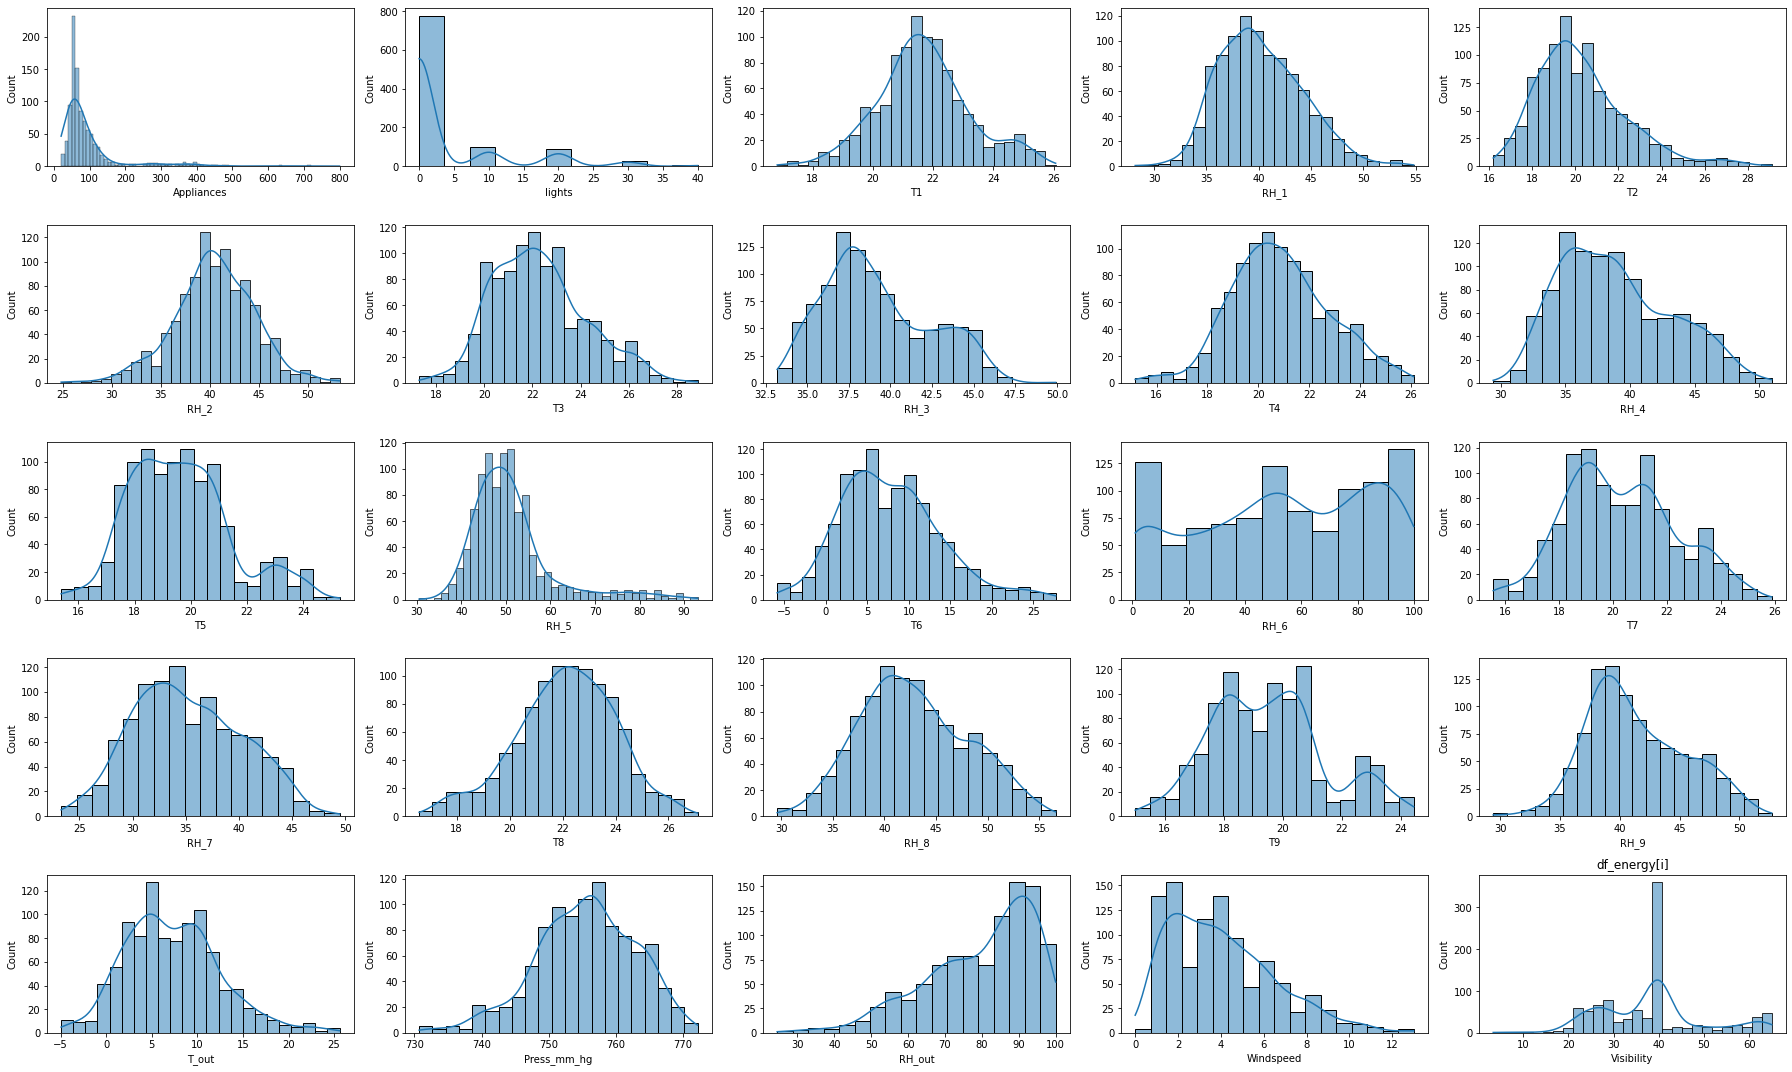

In [ ]:
fig, ax= plt.subplots(5,5, figsize=(25,15))

for i, subplot in zip(cols, ax.flatten()):
    sns.histplot(df_energy[i], ax=subplot,kde=True)
    plt.title('df_energy[i]')

plt.tight_layout()
plt.show()

1. Light and Appliances are discrete variable.
2. All other variables are continuous.

In [ ]:
df_energy.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,94.580000,3.880000,21.689083,40.220658,20.308276,40.456847,22.291003,39.193848,20.877548,38.883203,...,35.202685,22.110523,42.876733,19.500280,41.421305,7.270235,755.522126,79.722845,4.057964,38.219167
std,95.963705,8.075321,1.533835,3.966141,2.123854,4.080899,1.939537,3.171917,1.947205,4.297529,...,5.069127,1.877895,5.208331,1.926965,4.132533,5.207305,7.433976,14.623087,2.454295,11.679127
min,20.000000,0.000000,16.823333,28.193333,16.200000,24.823333,17.290000,33.200000,15.160000,29.421429,...,23.290000,16.583333,29.600000,15.000000,29.426667,-4.955556,730.700000,24.500000,0.000000,3.333333
25%,50.000000,0.000000,20.790000,37.200000,18.790000,38.057500,20.823333,36.900000,19.566667,35.484167,...,31.352738,20.910625,39.200000,18.100000,38.421429,3.537500,750.800000,70.000000,2.000000,28.666667
50%,60.000000,0.000000,21.600000,39.700000,19.890000,40.400000,22.100000,38.500000,20.760000,38.290000,...,34.609111,22.200000,42.352333,19.500000,40.566667,6.841667,755.941667,83.833333,3.666667,40.000000
75%,100.000000,0.000000,22.533333,42.861667,21.390000,43.200000,23.390000,41.500000,22.100000,41.992500,...,39.000000,23.441857,46.430694,20.600000,44.308333,10.433333,760.937500,91.333333,5.666667,40.000000
max,800.000000,40.000000,26.066667,54.800000,29.100000,53.249880,28.867143,49.930000,26.100000,50.963333,...,49.444444,27.100000,56.598333,24.434000,52.700000,25.600000,772.200000,100.000000,13.000000,65.000000


**Boxplots**

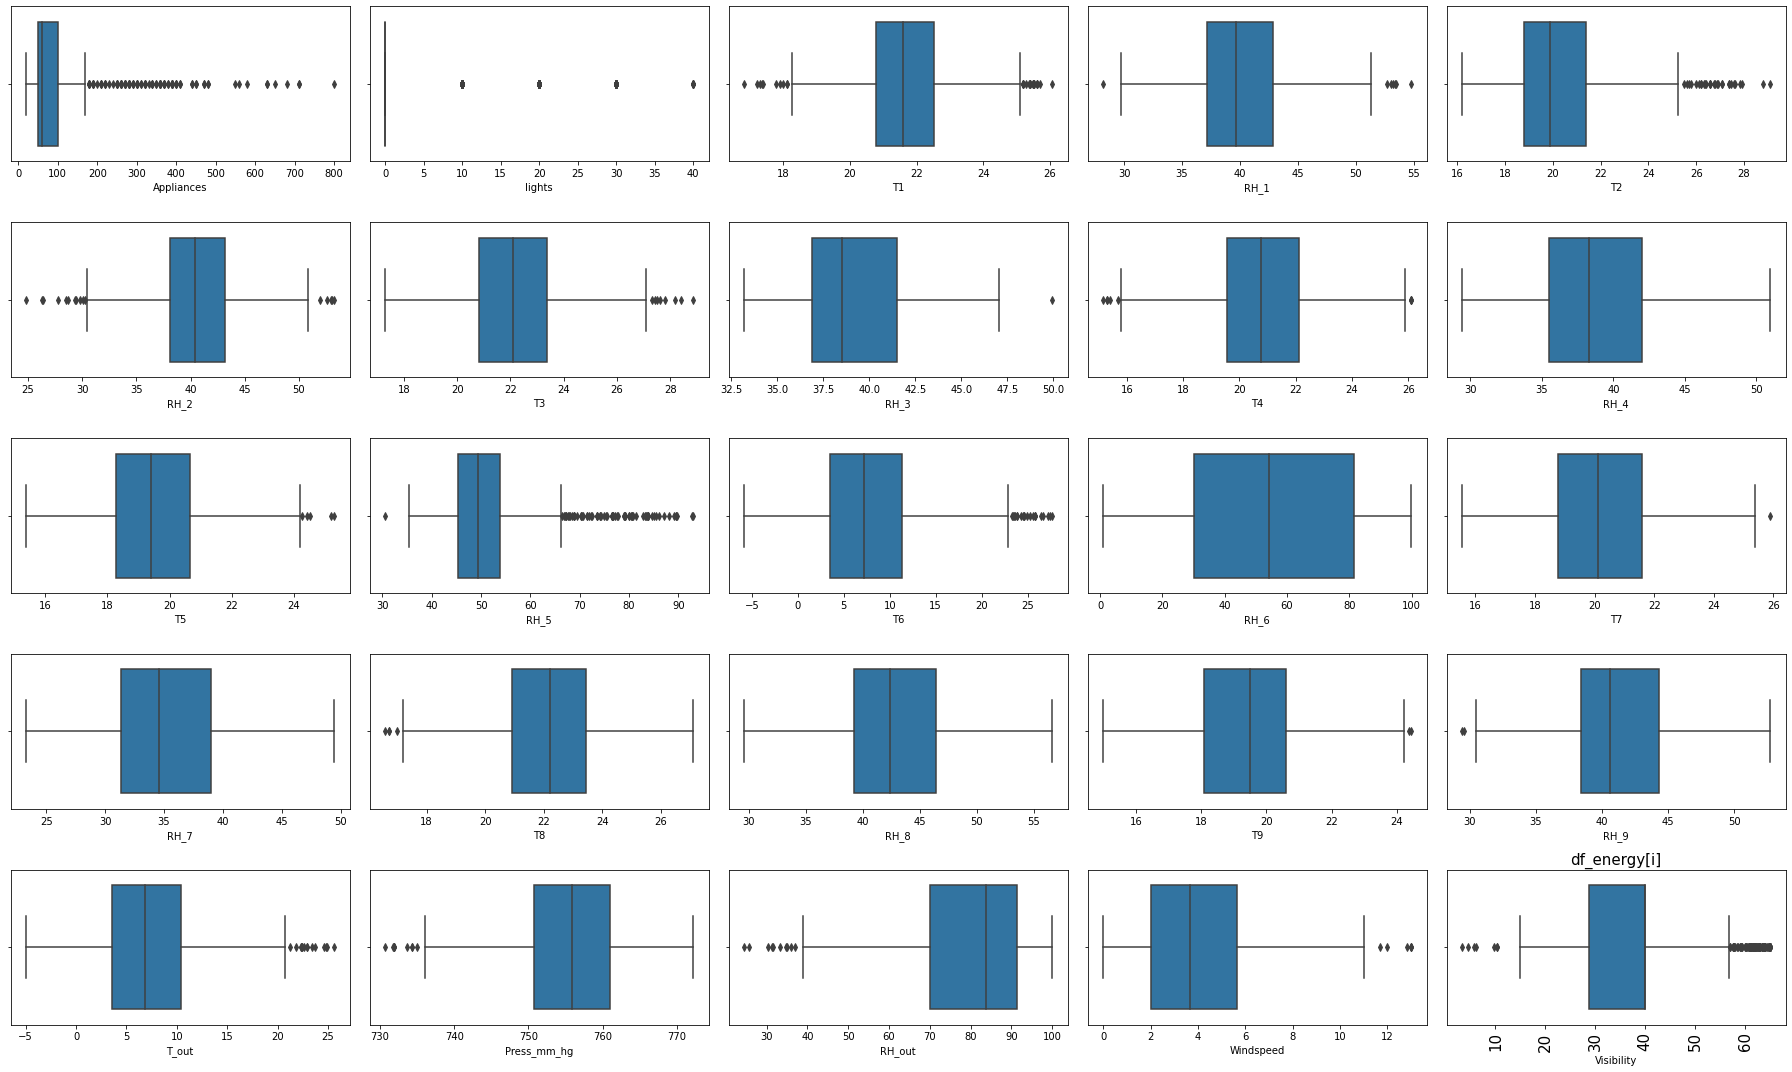

In [ ]:
fig, ax= plt.subplots(5,5, figsize=(25,15))

for i, subplot in zip(cols, ax.flatten()):
    sns.boxplot(df_energy[i], ax=subplot)
    plt.title('df_energy[i]', fontsize=15)
    plt.xticks(rotation = 'vertical', fontsize = 15)

plt.tight_layout()
plt.show()

Do not follow this coding style for boxplot

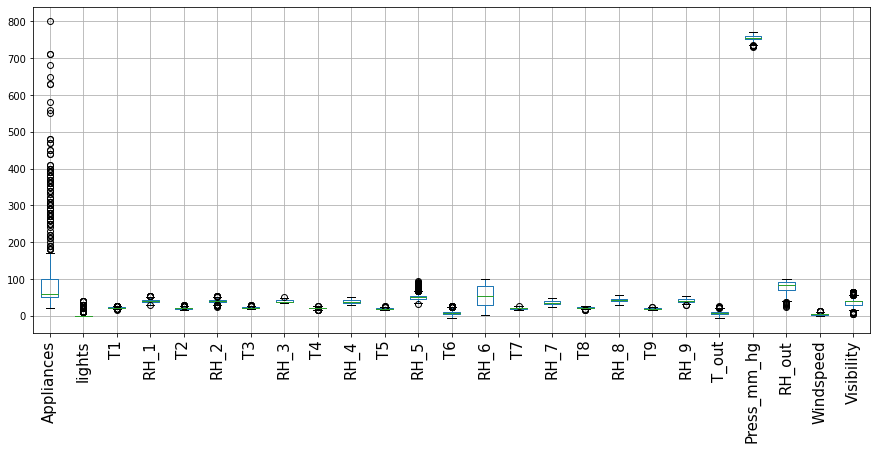

In [ ]:
df_energy.boxplot()

plt.xticks(rotation = 'vertical', fontsize = 15)

# display the plot
plt.show()

**Bivariate Analysis**

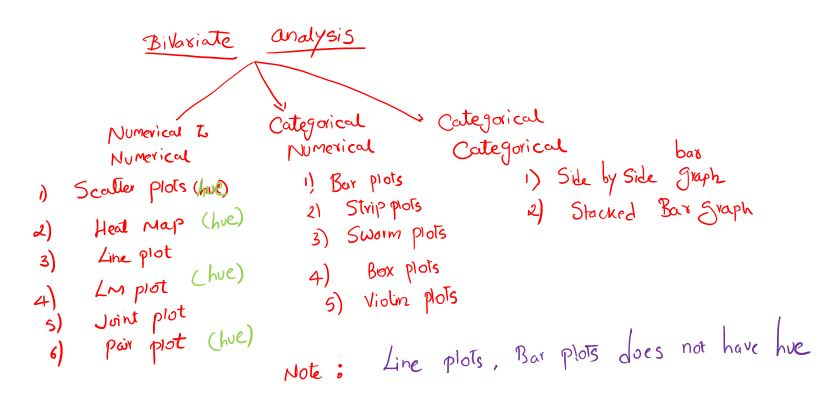

In [ ]:
from IPython.display import Image
Image(filename='Bivariate.JPG',width=600,height=300)

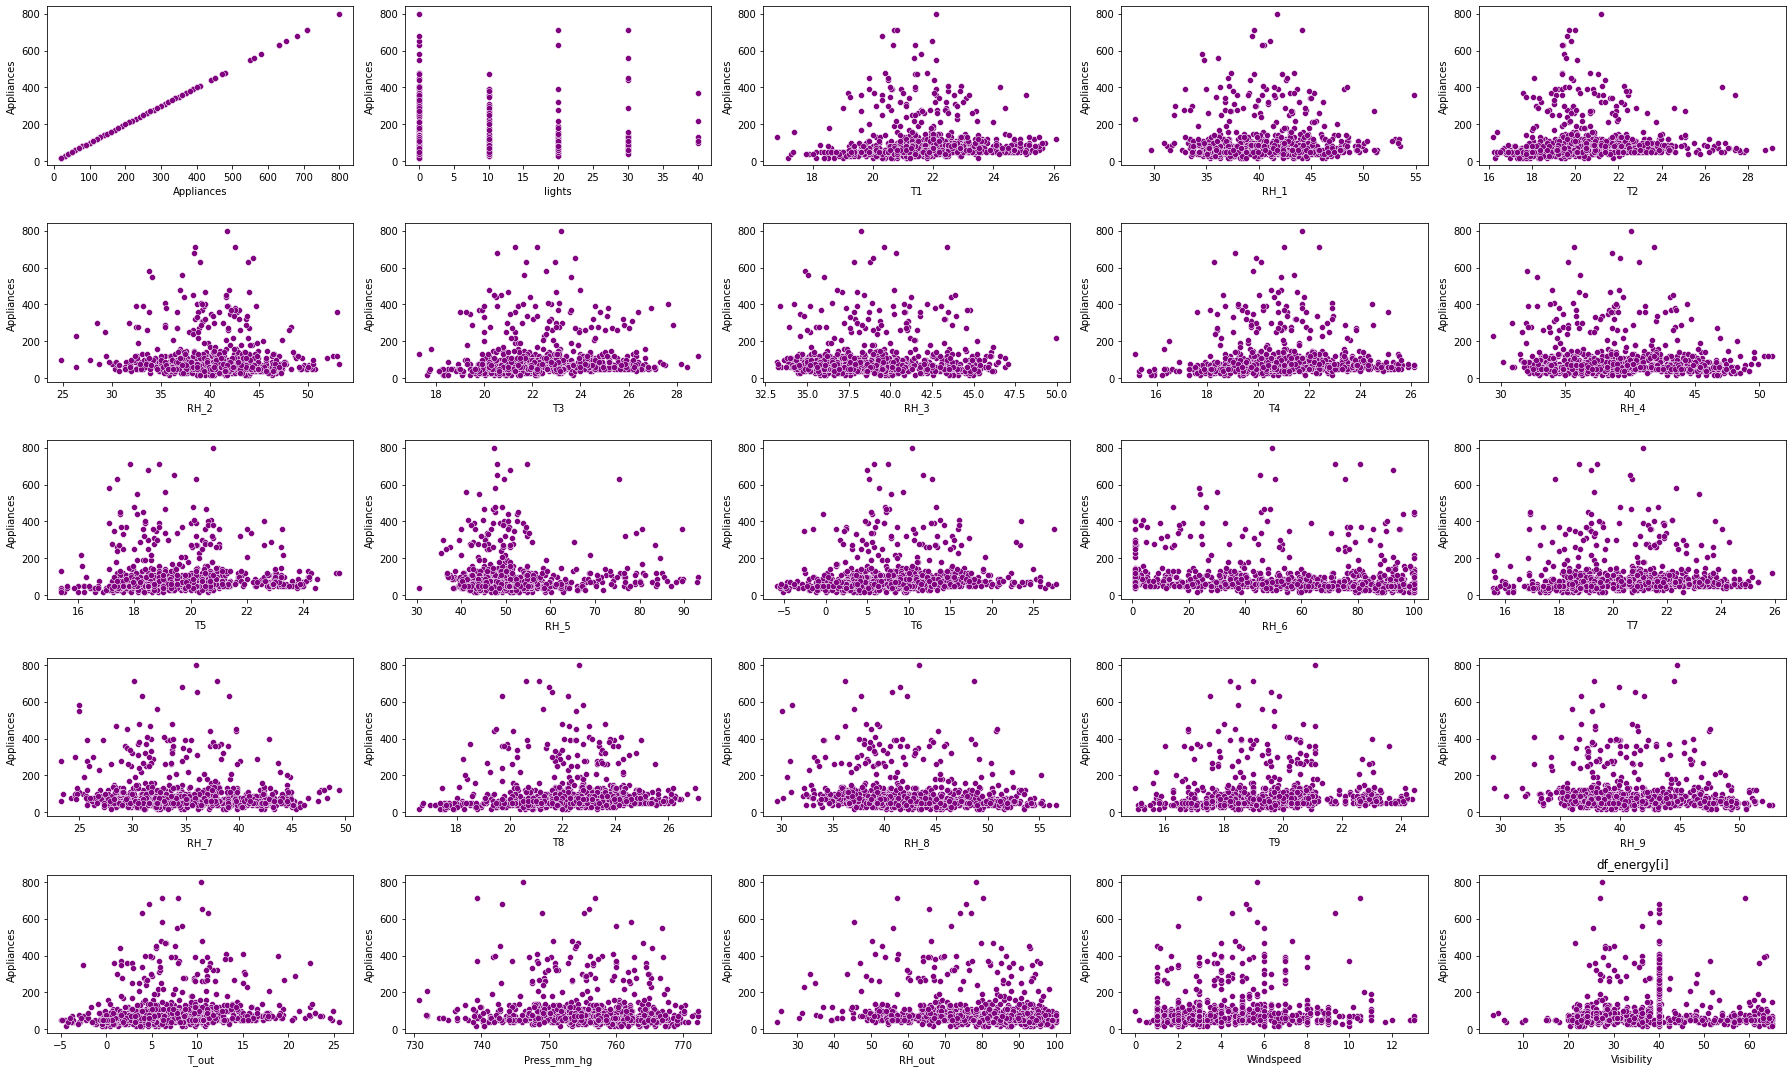

In [ ]:
fig, ax= plt.subplots(5,5, figsize=(25,15))

for i, subplot in zip(cols, ax.flatten()):
    sns.scatterplot(df_energy[i],df_energy['Appliances'], ax=subplot,color='purple')
    plt.title('df_energy[i]')

plt.tight_layout()
plt.show()

**Lets check the correlation between Independent variable**

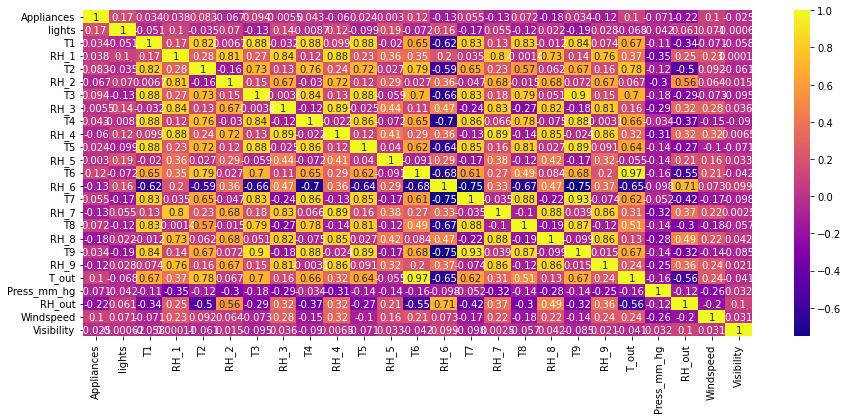

In [ ]:
sns.heatmap(df_energy.corr(),annot=True,cmap="plasma")
plt.show()

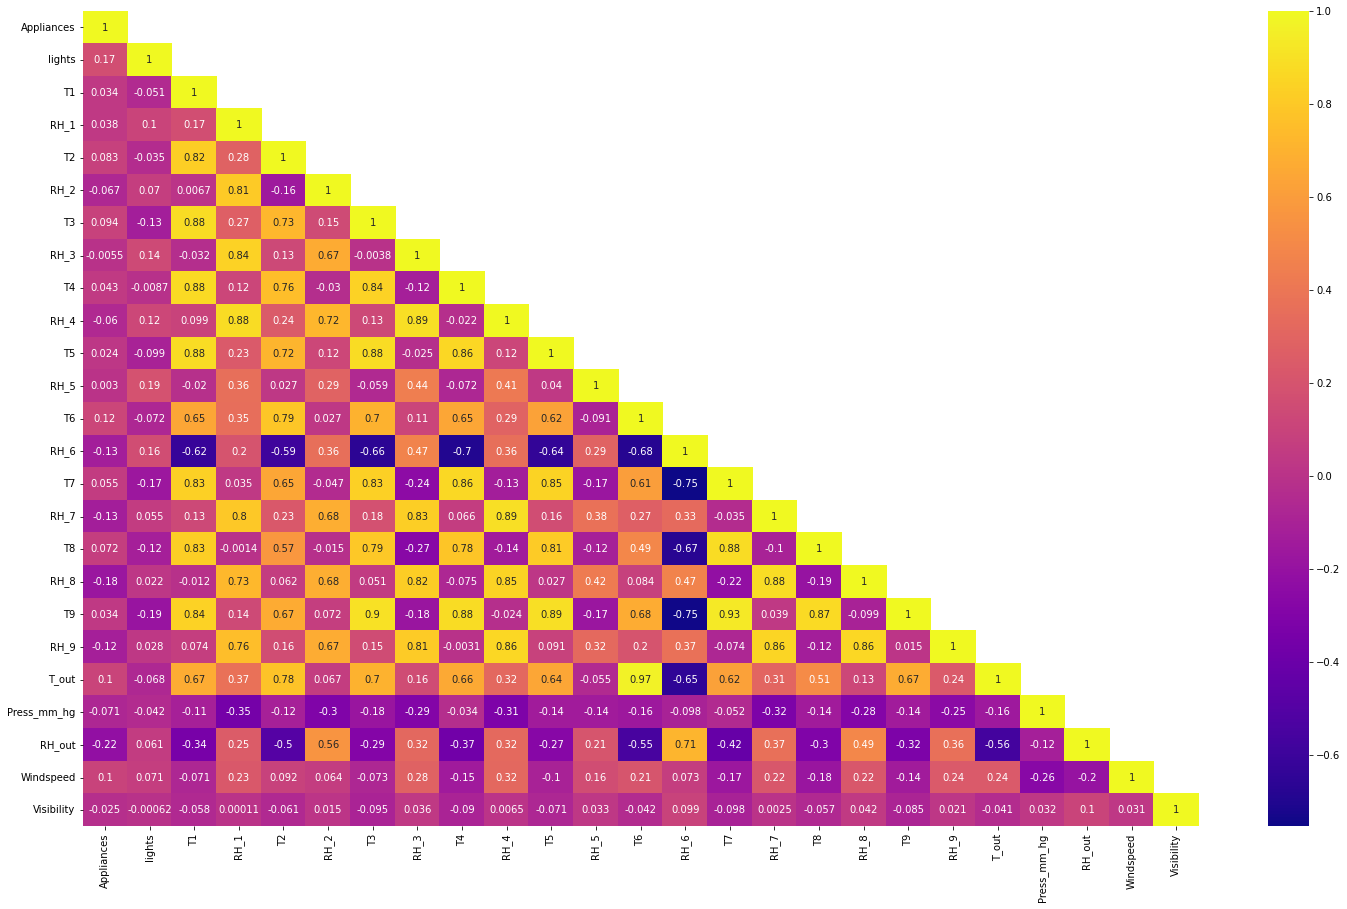

In [ ]:
plt.figure(figsize=(25,15))
sns.heatmap(df_energy.corr(),annot=True,cmap='plasma',mask=np.triu(df_energy.corr(),+1))
plt.show()

### Remove the Outliers

1. iqr = q3-q1
2. Value > q3+1.5 * iqr
3. value < q1-1.5 * iqr

In [ ]:
df_energy.shape

(1000, 25)

In [ ]:
q1 =df_energy.quantile(0.25)
q3= df_energy.quantile(0.75)
iqr=q3-q1

upper_limit= q3+1.5*iqr
lower_limit= q1-1.5*iqr

In [ ]:
upper_limit

Appliances     175.000000
lights           0.000000
T1              25.148333
RH_1            51.354167
T2              25.290000
RH_2            50.913750
T3              27.240000
RH_3            48.400000
T4              25.900000
RH_4            51.755000
T5              24.231667
RH_5            66.387357
T6              22.966250
RH_6           159.090833
T7              25.815000
RH_7            50.470893
T8              27.238705
RH_8            57.276736
T9              24.350000
RH_9            53.138690
T_out           20.777083
Press_mm_hg    776.143750
RH_out         123.333333
Windspeed       11.166667
Visibility      57.000000
dtype: float64

1. '~' returns the values that do not satisfy the given conditions 
i.e. it returns values between the range [Q1-1.5*IQR, Q3+1.5*IQR]
2. '|' is used as 'OR' operator on multiple conditions   
3. 'any(axis=1)' checks the entire row for atleast one 'True' entry (those rows represents outliers in the data)

In [ ]:
#~(df_emp > upper_limit ) | (df_emp < lower_limit).any(axis=1)
df_energy = df_energy[~((df_energy < (lower_limit)) | (df_energy > (upper_limit))).any(axis=1)]
df_energy.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility
1,60,0,21.290000,37.863333,19.390000,39.663333,21.790000,36.700000,20.463333,37.526667,...,32.095000,22.000000,39.223333,19.600000,38.826667,8.350000,761.800000,70.000000,3.500000,40.000000
2,80,0,21.390000,35.790000,19.290000,37.700000,22.760000,34.290000,21.323333,34.730000,...,29.200000,22.390000,37.290000,19.463333,35.500000,6.866667,762.333333,69.666667,3.000000,35.666667
3,40,0,19.033333,41.826667,18.533333,41.290000,18.100000,43.790000,15.890000,47.530000,...,40.138889,19.594444,51.062778,15.100000,46.760000,5.133333,769.583333,92.000000,4.833333,23.166667
5,50,0,21.840000,42.745000,19.760000,45.430000,24.066667,39.723333,21.600000,40.218000,...,36.500000,22.873333,46.900000,21.000000,45.590000,8.800000,745.500000,89.333333,4.333333,24.333333
7,110,0,22.463333,39.260000,21.290000,39.530000,22.700000,37.700000,21.200000,38.626667,...,32.790000,24.033333,38.360000,20.323333,38.000000,9.216667,753.366667,71.333333,3.666667,40.000000


In [ ]:
df_energy.shape

(543, 25)

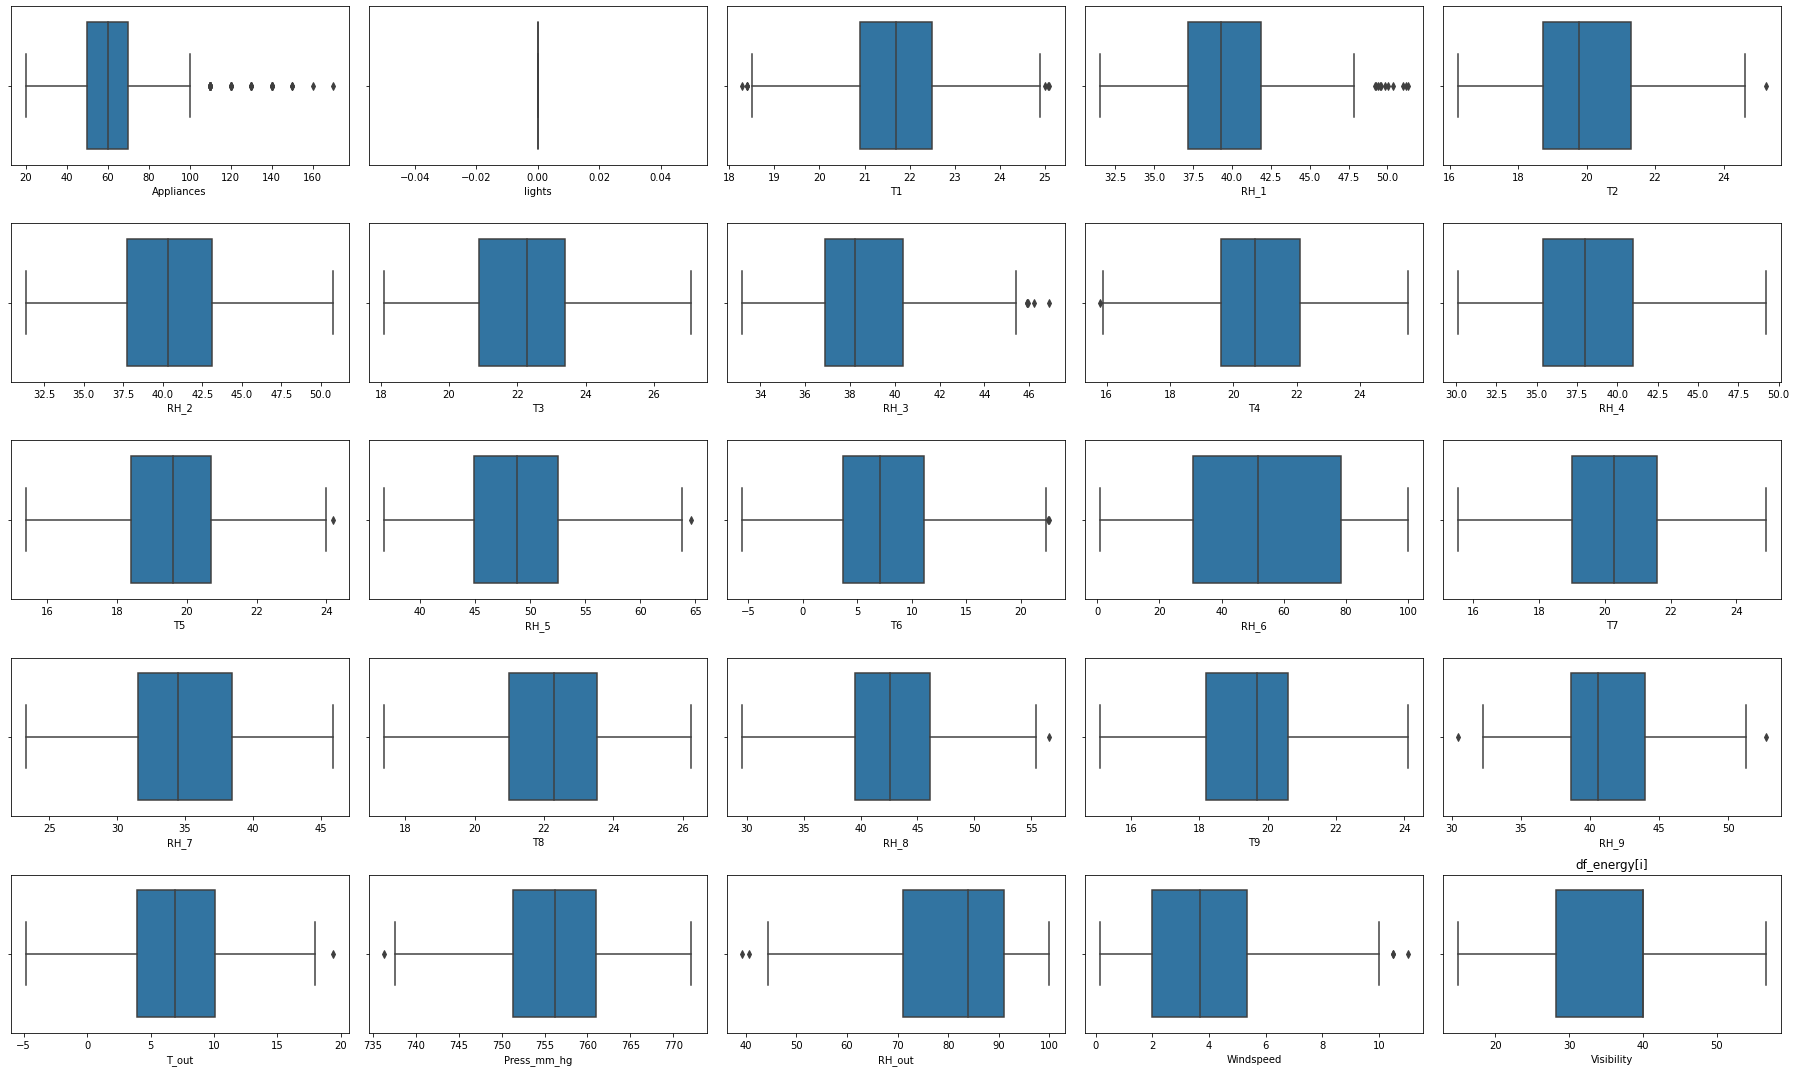

In [ ]:
fig, ax= plt.subplots(5,5, figsize=(25,15))

for i, subplot in zip(cols, ax.flatten()):
    sns.boxplot(df_energy[i], ax=subplot)
    plt.title('df_energy[i]')

plt.tight_layout()
plt.show()

In [ ]:
# def cap_outlier(val):
#     Q1, Q3 = np.quantile(val, [.25, .75])
#     IQR = Q3 - Q1
#     LL = Q1 - 1.5*IQR
#     UL = Q3 + 1.5*IQR
#     return LL, UL

In [ ]:
# for i in cols:
#     LL, UL = cap_outlier(df_emp[i])
#     df_emp[i] = np.where(df_emp[i]> UL, UL, df_emp[i])
#     df_emp[i] = np.where(df_emp[i]< LL, LL, df_emp[i])

**Check for presence of Insignificant Variables from Model Perspective**

In [ ]:
df_energy.std()

Appliances     25.658997
lights          0.000000
T1              1.418813
RH_1            3.579217
T2              1.821311
RH_2            3.803841
T3              1.784325
RH_3            2.978032
T4              1.810984
RH_4            4.079861
T5              1.666814
RH_5            5.473533
T6              5.325781
RH_6           29.376223
T7              1.898608
RH_7            4.663495
T8              1.832304
RH_8            4.976368
T9              1.813200
RH_9            3.973931
T_out           4.615927
Press_mm_hg     6.922218
RH_out         13.365639
Windspeed       2.279804
Visibility      8.582396
dtype: float64

1. Light has zero std which means there is no contribution from this variable. Good to remove this variable.

In [ ]:
df_energy = df_energy.drop('lights',axis=1)

### Encoding Techniques

All the Variables are Numerical and hence we do not require any Encoding Technique

### Transformation of Variables

1. Square Root Transformation
2. Cube Root Transformation
3. Log Transformation
4. Box Cox Transformation
5. Yeo Johnson Transformation

### Modeling

1. Split the Train and Test Data
2. SKLearn Linear Regression
3. Check the RMSE and R2 square value of the model
4. Improvise the model
5. Get the Statistical Summary and calculate the values that are generated.
6. Check the Assumption of the data.
7. Feature Selection.
8. Cross Validation.

In [ ]:
df_energy.columns

Index(['Appliances', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4',
       'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9',
       'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility'],
      dtype='object')

## Lets Build SKLearn Model First

In [ ]:
#split the data in x and y
X = df_energy.drop("Appliances",axis=1)
y = df_energy['Appliances']

In [ ]:
# sklearn model
# split the data in Train and Test

from sklearn.model_selection import train_test_split
# take all the x together and then all y together.

xtrain,xtest,ytrain,ytest = train_test_split(X,y,
                                             test_size=0.20,
                                             random_state=1)

**Find the distribution of the data in xtrain and xtest as well as ytrain and ytest**

In [ ]:
xtrain.head()

,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,...,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility
559,19.55,43.90,18.890000,43.590000,20.000000,44.790000,16.600000,46.4,16.700000,51.720000,...,42.535,18.740000,52.438889,16.390,48.433333,8.900000,758.350000,84.500000,10.500000,33.000000
488,24.10,41.20,23.230000,40.560000,25.200000,39.126667,23.633333,41.0,23.318571,53.295714,...,35.200,24.700000,42.054000,22.745,39.425000,12.616667,759.266667,70.000000,3.833333,38.166667
791,19.89,37.09,16.790000,40.933333,20.290000,37.900000,18.700000,35.2,17.760000,47.090000,...,35.200,20.033333,43.766667,17.600,39.900000,3.750000,749.816667,73.333333,7.000000,40.000000
862,21.89,44.50,20.426667,46.000000,23.100000,41.790000,21.100000,44.0,19.790000,49.700000,...,40.200,23.890000,51.933333,20.390,47.230000,13.500000,748.583333,83.833333,2.833333,28.500000
583,24.10,47.79,22.500000,49.126667,25.323333,42.700000,23.390000,45.4,22.890000,50.290000,...,41.000,24.290000,46.900000,23.100,47.400000,12.916667,755.616667,84.000000,2.833333,40.000000


In [ ]:
print(xtrain.shape)
print(xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(434, 23)
(109, 23)
(434,)
(109,)


1. **We will train the model on xtrain and ytrain and then test the model on xtest**
2. **Compare the performance using ytest**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

**Over Fitting and Underfitting Conditions**

1. If the training error and testing error has large variance then it is case of overfitting.
2. In overfitting condition, machine learns very well on training data but it is generalise on unseen test set
3. If the train error and test error are high then this is case of underfitting.
4. In underfitting conditions, machine does not learn well on training data as well as does not perform well on test data.
5. Overfitting conditions are High variane and underfitting conditions are high bias condition.

**Build the Basic Model to check the Overfit and Underfit conditions**

In [ ]:
lr=LinearRegression()

# build the model and find the r2score with RMSE

model_lr = lr.fit(xtrain,ytrain)

pred_train = model_lr.predict(xtrain)

pred_test=model_lr.predict(xtest)

In [ ]:
print("Train Predicted" , pd.DataFrame(pred_train).head())
print("Test Predicted"  , pd.DataFrame(pred_test).head())

Train Predicted            0
0  46.266244
1  80.765328
2  46.582566
3  59.271184
4  61.324547
Test Predicted             0
0   84.041177
1   67.652396
2   69.466279
3  102.718535
4   69.275550


In [ ]:
print("Shape of Train Predicted", pred_train.shape)
print("Shape of Test Predicted",  pred_test.shape)

Shape of Train Predicted (434,)
Shape of Test Predicted (109,)


In [ ]:
r2_train = r2_score(ytrain,pred_train)
r2_test =  r2_score(ytest ,pred_test)

print("R2 Train: ", r2_train)
print("R2 Test:  ", r2_test)

R2 Train:  0.35151069606491436
R2 Test:   0.26789576435436235


**Calculate the RMSE AND MSE VALUES**

In [ ]:
# Mean Squared Error
print("MSE Train :", mean_squared_error(ytrain,pred_train))
print("MSE Test  :", mean_squared_error(ytest,pred_test))


print("RMSE Train :", np.sqrt(mean_squared_error(ytrain,
                                                 pred_train)))

print("RMSE Test  :", np.sqrt(mean_squared_error(ytest,
                                                 pred_test)))

MSE Train : 450.9365240349773
MSE Test  : 367.8329285635106
RMSE Train : 21.235266045778125
RMSE Test  : 19.178970998557524


1. The model is not a overfit condition.
2. R2 is very low.
3. RMSE value is very high.

In [ ]:
pd.DataFrame(pred_train).describe()

,0
count,434.000000
mean,63.294931
std,15.652240
min,26.303973
25%,51.702077
50%,59.959962
75%,73.695193
max,143.611226


In [ ]:
pd.DataFrame(pred_test).describe()

,0
count,109.000000
mean,62.853603
std,14.298656
min,29.525326
25%,52.196842
50%,62.227672
75%,70.844553
max,102.718535


1. There are no negative values. These are energy predictions
2. There are no Zero values. These are the energy predictions.

**Lets Test this with a Different Model Like Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf=RandomForestRegressor()

# build the model and find the r2score with RMSE

rf = rf.fit(xtrain,ytrain)

pred_train_rf = rf.predict(xtrain)

pred_test_rf=rf.predict(xtest)

In [ ]:
# Mean Squared Error
print("MSE Train :", mean_squared_error(ytrain,pred_train_rf))
print("MSE Test  :", mean_squared_error(ytest,pred_test_rf))


print("RMSE Train :", np.sqrt(mean_squared_error(ytrain,
                                                 pred_train_rf)))

print("RMSE Test  :", np.sqrt(mean_squared_error(ytest,
                                                 pred_test_rf)))

MSE Train : 73.39981566820276
MSE Test  : 388.9393577981652
RMSE Train : 8.567369238465375
RMSE Test  : 19.721545522553885


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr=GradientBoostingRegressor()

# build the model and find the r2score with RMSE

gbr = gbr.fit(xtrain,ytrain)

pred_train_gbr = gbr.predict(xtrain)

pred_test_gbr=gbr.predict(xtest)

In [ ]:
# Mean Squared Error
print("MSE Train :", mean_squared_error(ytrain,pred_train_gbr))
print("MSE Test  :", mean_squared_error(ytest,pred_test_gbr))


print("RMSE Train :", np.sqrt(mean_squared_error(ytrain,
                                                 pred_train_gbr)))

print("RMSE Test  :", np.sqrt(mean_squared_error(ytest,
                                                 pred_test_gbr)))

MSE Train : 114.11374641202191
MSE Test  : 412.1272822512293
RMSE Train : 10.682403587770962
RMSE Test  : 20.300918261281417


**Lets build the Statistical Model to get more insights**

In [ ]:
df_energy.columns

Index(['Appliances', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4',
       'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9',
       'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility'],
      dtype='object')

In [ ]:


X = df_energy.drop("Appliances",axis=1)
y = df_energy['Appliances']

In [ ]:
import statsmodels.api as sma

temp_x = sma.add_constant(X)
x_train,x_test,y_train,y_test = train_test_split(temp_x,y,
                                             test_size=0.20,
                                             random_state=1)

In [ ]:
print('x_train', x_train.shape)
print('y_train', y_train.shape)

# print dimension of test set
print('x_test', x_test.shape)
print('y_test', y_test.shape)

x_train (434, 24)
y_train (434,)
x_test (109, 24)
y_test (109,)


In [ ]:
sma.add_constant(x_train)   
# this constant will tell to calculate the intercept.

,const,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility
559,1.0,19.550000,43.900000,18.890000,43.590000,20.000000,44.790000,16.600000,46.400000,16.700000,...,42.535000,18.740000,52.438889,16.390000,48.433333,8.900000,758.350000,84.500000,10.500000,33.000000
488,1.0,24.100000,41.200000,23.230000,40.560000,25.200000,39.126667,23.633333,41.000000,23.318571,...,35.200000,24.700000,42.054000,22.745000,39.425000,12.616667,759.266667,70.000000,3.833333,38.166667
791,1.0,19.890000,37.090000,16.790000,40.933333,20.290000,37.900000,18.700000,35.200000,17.760000,...,35.200000,20.033333,43.766667,17.600000,39.900000,3.750000,749.816667,73.333333,7.000000,40.000000
862,1.0,21.890000,44.500000,20.426667,46.000000,23.100000,41.790000,21.100000,44.000000,19.790000,...,40.200000,23.890000,51.933333,20.390000,47.230000,13.500000,748.583333,83.833333,2.833333,28.500000
583,1.0,24.100000,47.790000,22.500000,49.126667,25.323333,42.700000,23.390000,45.400000,22.890000,...,41.000000,24.290000,46.900000,23.100000,47.400000,12.916667,755.616667,84.000000,2.833333,40.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,1.0,23.200000,38.000000,22.790000,36.117500,22.790000,38.090000,22.100000,36.975000,21.200000,...,30.890000,23.500000,35.500000,20.856667,39.500000,14.800000,751.366667,55.333333,4.666667,40.000000
287,1.0,21.066667,46.163333,19.790000,46.433333,21.700000,43.000000,20.133333,45.626667,18.500000,...,44.430000,20.390000,48.933333,18.700000,47.272000,6.800000,751.150000,97.500000,5.500000,51.500000
150,1.0,19.100000,39.900000,17.823333,40.360000,19.000000,39.663333,18.100000,37.200000,16.500000,...,32.200000,19.463333,40.375556,16.890000,38.326667,1.066667,757.233333,60.666667,1.000000,25.333333
476,1.0,19.890000,45.500000,19.200000,45.030000,20.500000,44.400000,19.066667,46.760000,17.516667,...,43.488889,18.133333,50.000000,17.133333,48.700000,10.500000,761.700000,82.000000,8.000000,27.000000


In [ ]:
model = sma.OLS(y_train,x_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Appliances   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     9.663
Date:                Tue, 31 Jan 2023   Prob (F-statistic):           1.09e-26
Time:                        23:23:31   Log-Likelihood:                -1942.0
No. Observations:                 434   AIC:                             3932.
Df Residuals:                     410   BIC:                             4030.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          30.5038    157.184      0.194      0.846    -278.484     339.492
T1              1.6850      3.239      0.520      0.603      -4.683       8.053
RH_1            5.7350      1.404      4.084      0.000       2.974       8.496
T2             -7.0984      2.915     -2.435      0.015     -12.829      -1.368
RH_2           -4.4119      1.387     -3.181      0.002      -7.139      -1.685
T3              4.7152      1.865      2.528      0.012       1.049       8.382
RH_3            0.0217      1.275      0.017      0.986      -2.485       2.528
T4              3.2258      2.027      1.591      0.112      -0.759       7.210
RH_4            1.0482      1.182      0.887      0.376      -1.275       3.372
T5              0.2366      2.129      0.111      0.912      -3.949       4.422
RH_5           -0.0046      0.275     -0.017      0.987      -0.546       0.537
T6              1.4891      0.949      1.569      0.117      -0.377       3.355
RH_6            0.0480      0.107      0.447      0.655      -0.163       0.259
T7             -4.4128      2.288     -1.928      0.055      -8.911       0.086
RH_7            0.5859      0.676      0.867      0.387      -0.743       1.915
T8             11.1364      1.670      6.667      0.000       7.853      14.420
RH_8           -2.9775      0.588     -5.061      0.000      -4.134      -1.821
T9             -8.3401      3.044     -2.740      0.006     -14.324      -2.356
RH_9           -0.8892      0.663     -1.341      0.181      -2.192       0.414
T_out          -0.5231      1.100     -0.476      0.634      -2.685       1.638
Press_mm_hg     0.0053      0.191      0.028      0.978      -0.371       0.381
RH_out          0.0488      0.192      0.255      0.799      -0.328       0.426
Windspeed       1.1656      0.592      1.969      0.050       0.002       2.329
Visibility     -0.0091      0.129     -0.071      0.943      -0.262       0.244
==============================================================================
Omnibus:                      128.702   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              428.410
Skew:                           1.340   Prob(JB):                     9.37e-94
Kurtosis:                       7.063   Cond. No.                     1.16e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.16e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

https://medium.com/swlh/interpreting-linear-regression-through-statsmodels-summary-4796d359035a

**Are the Assumptions of Linear Regression Met**

**Linearity Test -Rainbow TEST**

### Linearity Assumption

### H0: Data has Linear Relationship with the Target Variable.
### Ha: Data has non Linear releationship with target variable

In [ ]:
sma.stats.linear_rainbow(model)

(0.6246692458297122, 0.9996121718905507)

### Normality Test

H0: Data/Residual are Normally distributed.

Ha: Data/Residuals are not Normally distributed.

In [ ]:
# residual is error = Yi -Yhat
stats.jarque_bera(model.resid)

Jarque_beraResult(statistic=428.4102665050727, pvalue=0.0)

1. The data is not normal. Can we reduce the skewness and make it close to Normal.
2. Does this improve the performance and RMSE Scores.
3. Which transformation techniques should we use ?

**Can we Improvise the MODEL ?**

**Step 1 : Lets Transform the Dependent Variable**

In [ ]:
from scipy import stats

**Lets take combination of all the transformation technique and see the performances**

In [ ]:
stats.boxcox(y_train)[0][0:3]   # the outputs from boxcox are fitted values(predicted) and lambda values.

array([3.40643809, 3.91560106, 3.40643809])

In [ ]:
model_boxcox= sma.OLS(stats.boxcox(y_train)[0], x_train).fit()

# print the summary output
print(model_boxcox.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.351
Model:                            OLS   Adj. R-squared:                  0.314
Method:                 Least Squares   F-statistic:                     9.630
Date:                Tue, 31 Jan 2023   Prob (F-statistic):           1.36e-26
Time:                        23:23:31   Log-Likelihood:                 13.413
No. Observations:                 434   AIC:                             21.17
Df Residuals:                     410   BIC:                             118.9
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           3.4724      1.737      2.000      

In [ ]:
model_sqrt= sma.OLS(np.sqrt(y_train), x_train).fit() # squared root transformation
model_cbrt= sma.OLS(np.cbrt(y_train), x_train).fit() # cube root transformation
model_log= sma.OLS(np.log(y_train), x_train).fit() # log transformation
model_yojh= sma.OLS(stats.yeojohnson(y_train)[0], x_train).fit() # YeoJohnson transformation

In [ ]:
cols = ["Transformation", "R_Squared", "Adj Rsquared"]
df_cols = pd.DataFrame(columns = cols)

model_Trans = pd.Series({"Transformation": "Square Root",
                        "R_Squared": model_sqrt.rsquared,
                         "Adj Rsquared": model_sqrt.rsquared_adj
                        })
result = df_cols.append(model_Trans, ignore_index = True)
result

,Transformation,R_Squared,Adj Rsquared
0,Square Root,0.360127,0.324231


In [ ]:
model_Trans = pd.Series({"Transformation": "Cube Root",
                        "R_Squared": model_cbrt.rsquared,
                         "Adj Rsquared": model_cbrt.rsquared_adj
                        })
result = result.append(model_Trans, ignore_index = True)



In [ ]:
model_Trans = pd.Series({"Transformation": "Log",
                        "R_Squared": model_log.rsquared,
                         "Adj Rsquared": model_log.rsquared_adj
                        })
result = result.append(model_Trans, ignore_index = True)

In [ ]:
model_Trans = pd.Series({"Transformation": "Box Cox",
                        "R_Squared": model_boxcox.rsquared,
                         "Adj Rsquared": model_boxcox.rsquared_adj
                        })
result = result.append(model_Trans, ignore_index = True)

In [ ]:
model_Trans = pd.Series({"Transformation": "Yeo Johnson",
                        "R_Squared": model_yojh.rsquared,
                         "Adj Rsquared": model_yojh.rsquared_adj
                        })
result = result.append(model_Trans, ignore_index = True)
result

,Transformation,R_Squared,Adj Rsquared
0,Square Root,0.360127,0.324231
1,Cube Root,0.359664,0.323743
2,Log,0.353168,0.316883
3,Box Cox,0.350749,0.314328
4,Yeo Johnson,0.350877,0.314462


None of The transformations have worked. So we rule out the use of Transformation Technique

**Can Feature selection help us to improve the model performance**

### Feature Selection

There are 2 ways for selecting the features : -

1. Sequential Feature Selection.
2. Recursive Feature Elimination.

1. Sequential Feature Selector (SFS)
2. Recursive Feature Elimination (RFE)
3. Split the data into Train and Test -Already done.
4. Build a Statistical Model. Check the p value and determine the significant features.

In [ ]:
import statsmodels.api as sma

***Statistical Way-Important Variable***

In [ ]:
import statsmodels.api as sma

model = sma.OLS(y_train, x_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Appliances   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     9.663
Date:                Tue, 31 Jan 2023   Prob (F-statistic):           1.09e-26
Time:                        23:23:32   Log-Likelihood:                -1942.0
No. Observations:                 434   AIC:                             3932.
Df Residuals:                     410   BIC:                             4030.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          30.5038    157.184      0.194      0.846    -278.484     339.492
T1              1.6850      3.239      0.520      0.603      -4.683       8.053
RH_1            5.7350      1.404      4.084      0.000       2.974       8.496
T2             -7.0984      2.915     -2.435      0.015     -12.829      -1.368
RH_2           -4.4119      1.387     -3.181      0.002      -7.139      -1.685
T3              4.7152      1.865      2.528      0.012       1.049       8.382
RH_3            0.0217      1.275      0.017      0.986      -2.485       2.528
T4              3.2258      2.027      1.591      0.112      -0.759       7.210
RH_4            1.0482      1.182      0.887      0.376      -1.275       3.372
T5              0.2366      2.129      0.111      0.912      -3.949       4.422
RH_5           -0.0046      0.275     -0.017      0.987      -0.546       0.537
T6              1.4891      0.949      1.569      0.117      -0.377       3.355
RH_6            0.0480      0.107      0.447      0.655      -0.163       0.259
T7             -4.4128      2.288     -1.928      0.055      -8.911       0.086
RH_7            0.5859      0.676      0.867      0.387      -0.743       1.915
T8             11.1364      1.670      6.667      0.000       7.853      14.420
RH_8           -2.9775      0.588     -5.061      0.000      -4.134      -1.821
T9             -8.3401      3.044     -2.740      0.006     -14.324      -2.356
RH_9           -0.8892      0.663     -1.341      0.181      -2.192       0.414
T_out          -0.5231      1.100     -0.476      0.634      -2.685       1.638
Press_mm_hg     0.0053      0.191      0.028      0.978      -0.371       0.381
RH_out          0.0488      0.192      0.255      0.799      -0.328       0.426
Windspeed       1.1656      0.592      1.969      0.050       0.002       2.329
Visibility     -0.0091      0.129     -0.071      0.943      -0.262       0.244
==============================================================================
Omnibus:                      128.702   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              428.410
Skew:                           1.340   Prob(JB):                     9.37e-94
Kurtosis:                       7.063   Cond. No.                     1.16e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.16e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

1. There are several variables whose p values are more than 0.05.
2. As per statistical model, there are several variables which are not important.
3. The best way is to eliminate these features.
4. Take only those features which are important and build the model.

**The above method is statistical way of finding the significant features and determine which features are important. We will try to find the important features through Machine learning.**

***Machine Learning Way- Important Variables***

In [ ]:
# Calculate the RMSE of Linear regression -ML Way
from sklearn.metrics import mean_squared_error

pred_test= model.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
print("RMSE Test  :", np.sqrt(mean_squared_error(y_test, pred_test)))



RMSE Test  : 19.1789709985576


In [ ]:
cols_sel = ["Model", "RMSE", "RSquared", "Adj_Rsquared"]
df_cols_sel = pd.DataFrame(columns = cols_sel)


model_stats = pd.Series({"Model": "Linear Regression",
                        "RMSE": rmse,
                        "RSquared": model.rsquared,
                        "Adj_Rsquared": model.rsquared_adj
                        })
result_Sel = df_cols_sel.append(model_stats, ignore_index = True)

result_Sel

,Model,RMSE,RSquared,Adj_Rsquared
0,Linear Regression,19.178971,0.351511,0.315132


**Lets Compare the results for different Selection Methods**

In [ ]:
import mlxtend
# from mlxtend.feature_selection import SequentialFeatureSelector

In [ ]:
import mlxtend.feature_extraction

In [ ]:
import joblib

In [ ]:
# !pip install mlxtend
import joblib
import sys
sys.modules['sklearn.externals.joblib'] = joblib
from mlxtend.feature_selection import SequentialFeatureSelector

**Forward Selection**

**Selecting features ML Way**

In [ ]:
lr = LinearRegression()

sfs_forward = SequentialFeatureSelector(estimator = lr, k_features=12,
                                forward = True, 
                                #verbose=2,
                                scoring = "r2") # This is how the programmer have designed at the backend.Error is
                                                                    # represented as Negative. This is an error. They want to signify this with negative.

**xtrain and ytrain are coming from the split done for lr.**

In [ ]:
xtrain.head(2)

,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,...,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility
559,19.55,43.9,18.89,43.59,20.0,44.790000,16.600000,46.4,16.700000,51.720000,...,42.535,18.74,52.438889,16.390,48.433333,8.900000,758.350000,84.5,10.500000,33.000000
488,24.10,41.2,23.23,40.56,25.2,39.126667,23.633333,41.0,23.318571,53.295714,...,35.200,24.70,42.054000,22.745,39.425000,12.616667,759.266667,70.0,3.833333,38.166667


In [ ]:
x_train.head(2)

,const,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility
559,1.0,19.55,43.9,18.89,43.59,20.0,44.790000,16.600000,46.4,16.700000,...,42.535,18.74,52.438889,16.390,48.433333,8.900000,758.350000,84.5,10.500000,33.000000
488,1.0,24.10,41.2,23.23,40.56,25.2,39.126667,23.633333,41.0,23.318571,...,35.200,24.70,42.054000,22.745,39.425000,12.616667,759.266667,70.0,3.833333,38.166667


In [ ]:
sfs_forward.fit(xtrain, ytrain)

SequentialFeatureSelector(estimator=LinearRegression(), k_features=12,
                          scoring='r2')

In [ ]:
sfs_forward.k_feature_names_

('RH_1',
 'RH_2',
 'T4',
 'T6',
 'RH_6',
 'T7',
 'T8',
 'RH_8',
 'T9',
 'RH_9',
 'T_out',
 'Windspeed')

Out of 25 features, SFS has selected the 12 features

In [ ]:
sfs_forward.k_score_

0.2942534612961302

In [ ]:
len(sfs_forward.k_feature_names_)

12

In [ ]:
# Print the list of 20 features
# Create a new dataframe with all the 20 features for train data and test data

sfs_features_forward = xtrain.loc[:, sfs_forward.k_feature_names_] # this is the list of best features
sfs_test_forward = xtest.loc[:, sfs_forward.k_feature_names_]

In [ ]:
sfs_forward.k_score_

0.2942534612961302

In [ ]:
cols_sel = ["Model", "K_Score"]
df_cols_sel = pd.DataFrame(columns = cols_sel)


model_stats = pd.Series({"Model": "Forward-12",
                        "K_Score": sfs_forward.k_score_                        
                        })
result_Sel = df_cols_sel.append(model_stats, ignore_index = True)

result_Sel

,Model,K_Score
0,Forward-12,0.294253


**Lets Selects features With Some Range**

In [ ]:
lr = LinearRegression()

sfs_forward = SequentialFeatureSelector(estimator = lr, k_features=(5,20),
                                forward = True, 
                                #verbose=2,
                                scoring = "r2") # This is how the programmer have designed at the backend.Error is
                                                                    # represented as Negative.

In [ ]:
sfs_forward.fit(xtrain, ytrain)
sfs_forward.k_feature_names_

('RH_1', 'RH_2', 'T4', 'RH_6', 'T7', 'T8', 'RH_8', 'T9', 'RH_9', 'Windspeed')

In [ ]:
len(sfs_forward.k_feature_names_)

10

In [ ]:
# Print the list of features between 5- 20
# Create a new dataframe with the features for train data and test data

sfs_features_forward = xtrain.loc[:, sfs_forward.k_feature_names_] # this is the list of best features
sfs_test_forward = xtest.loc[:, sfs_forward.k_feature_names_]

In [ ]:
sfs_forward.k_score_

0.29599807877184503

In [ ]:
# cols_sel = ["Model", "K_Score"]
# df_cols_sel = pd.DataFrame(columns = cols_sel)


model_stats = pd.Series({"Model": "Forward-Range",
                        "K_Score": sfs_forward.k_score_                        
                        })
result_Sel = result_Sel.append(model_stats, ignore_index = True)

result_Sel

,Model,K_Score
0,Forward-12,0.294253
1,Forward-Range,0.295998


**Selection of Best from 25 Features**

In [ ]:
sfs_forward = SequentialFeatureSelector(estimator = lr, k_features="best",
                                forward = True, 
                                #verbose=2,
                                scoring = "r2") # This is how the programmer have designed at the backend.Error is
                                                                    # represented as Negative.

In [ ]:
sfs_forward.fit(xtrain, ytrain)
sfs_forward.k_feature_names_

('RH_1', 'RH_2', 'T4', 'RH_6', 'T7', 'T8', 'RH_8', 'T9', 'RH_9', 'Windspeed')

In [ ]:
len(sfs_forward.k_feature_names_)

10

In [ ]:
# Print the list of best features
# Create a new dataframe with the features for train data and test data

sfs_features_forward = xtrain.loc[:, sfs_forward.k_feature_names_] # this is the list of best features
sfs_test_forward = xtest.loc[:, sfs_forward.k_feature_names_]

In [ ]:
sfs_forward.k_score_

0.29599807877184503

In [ ]:
# cols_sel = ["Model", "K_Score"]
# df_cols_sel = pd.DataFrame(columns = cols_sel)


model_stats = pd.Series({"Model": "Forward-Best",
                        "K_Score": sfs_forward.k_score_                        
                        })
result_Sel = result_Sel.append(model_stats, ignore_index = True)

result_Sel

,Model,K_Score
0,Forward-12,0.294253
1,Forward-Range,0.295998
2,Forward-Best,0.295998


### RFE AND KFOLD

**Recursive Feature Selection**

In [ ]:
from sklearn.feature_selection import RFE

lr =LinearRegression()

1. We do not have best number of features in RFE.
2. So, we need to give random numbers. This can be a guess.

In [ ]:
lr =LinearRegression()

rfe = RFE(estimator = lr, 
         n_features_to_select = 12)

         #k_features="best", # We do not have best in RFE. We need to provide number of features.
         # forward = True, # There is no forward selection or backward elimination approach  
         # scoring = "neg_mean_squared_error") # There is no scoring too in RFE.

**RFE gives feature ranking**

In [ ]:
rfe.fit(xtrain,ytrain)

RFE(estimator=LinearRegression(), n_features_to_select=12)

**With n_features, it gives the top 5 features with a rank of 1. All others features will follow with a lower rank from 2.**

In [ ]:
pd.DataFrame(rfe.ranking_,index=xtrain.columns)

,0
T1,2
RH_1,1
T2,1
RH_2,1
T3,1
RH_3,9
T4,1
RH_4,1
T5,6
RH_5,12


In [ ]:
pd.Series(rfe.ranking_,index=xtrain.columns).sort_values(ascending=True)

RH_9            1
RH_1            1
T2              1
RH_2            1
T3              1
RH_8            1
T4              1
RH_4            1
T9              1
T8              1
T7              1
Windspeed       1
T1              2
T6              3
T_out           4
RH_7            5
T5              6
RH_out          7
RH_6            8
RH_3            9
Visibility     10
Press_mm_hg    11
RH_5           12
dtype: int64

**Take the Features and build the model**

In [ ]:
feature_index = pd.Series(rfe.ranking_,index=xtrain.columns).sort_values(ascending=False)

In [ ]:
impfeature_rfe = feature_index[feature_index==1].index

In [ ]:
impfeature_rfe

Index(['T9', 'Windspeed', 'T2', 'RH_9', 'T3', 'RH_8', 'T4', 'T7', 'RH_1',
       'RH_2', 'RH_4', 'T8'],
      dtype='object')

In [ ]:
rfe_train = xtrain.loc[:,impfeature_rfe]
rfe_test =xtest.loc[:,impfeature_rfe]

In [ ]:
rfe_train.shape

(434, 12)

In [ ]:
rfe_test.shape

(109, 12)

In [ ]:
linreg = LinearRegression()

# build the model using new_X_train and y_train
linreg.fit(rfe_train, ytrain)

# check the score
print("Score on Training",linreg.score(rfe_train, ytrain))
print("Score on Testing",linreg.score(rfe_test, ytest))

rfe_score = linreg.score(rfe_train, ytrain)


Score on Training 0.34090455423132326
Score on Testing 0.26353360629206124


In [ ]:
model_stats = pd.Series({"Model": "RFE",
                        "K_Score": rfe_score                        
                        })
result_Sel = result_Sel.append(model_stats, ignore_index = True)

result_Sel

,Model,K_Score
0,Forward-12,0.294253
1,Forward-Range,0.295998
2,Forward-Best,0.295998
3,RFE,0.340905


### KFOLD Cross Validation

In [ ]:
X = df_energy.drop('Appliances', axis = 1)

# consider the dependent variable
y = df_energy['Appliances']

In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,
                                             test_size=0.20,
                                             random_state=1)

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

**shuffle : It creates one sample and then shuffles the rest of the dataset and then creates the next sample. It keeps creating one sample after the another and shuffles the dataset. This is to do randomization. By default it is set to False. It increases the time**

In [ ]:
kf=KFold(n_splits=5, shuffle=True,random_state=1)

**Lets see this 5 parts**

1. This has only the training data. There is no test data here.
2. It has divided into 5 parts and the train index is the row number
3. Split has happened randomly.

In [ ]:
for train_index, test_index in kf.split(xtrain):
  print(train_index,test_index)

[  0   1   2   3   7   8   9  10  11  12  13  14  15  16  19  20  21  22
  23  24  25  26  27  28  30  31  32  33  34  35  36  37  38  39  41  42
  43  44  45  46  48  49  50  51  52  53  54  55  56  57  59  60  61  63
  64  66  68  69  70  71  72  73  74  75  76  77  79  80  81  82  83  84
  85  86  87  88  89  91  92  93  94  95  96  97  98  99 100 102 103 104
 105 106 107 108 109 110 111 112 113 114 115 116 118 120 121 123 124 125
 126 127 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 147 148 149 150 151 152 153 154 155 156 157 158 159 160 163 165 166
 167 169 170 174 175 176 177 178 179 181 182 183 184 185 186 187 188 189
 190 193 194 195 196 197 198 199 200 202 203 205 207 209 210 211 212 215
 216 217 219 220 222 224 226 227 229 231 232 234 235 236 237 239 240 241
 242 243 245 247 248 250 252 253 254 255 256 257 259 260 261 262 263 264
 265 266 267 269 271 273 275 276 277 278 279 280 281 282 283 285 286 288
 290 291 293 295 296 297 298 299 301 302 303 304 30

In [ ]:
lr = LinearRegression()
predictions_ml = []
scores_kf = []

for train_index, test_index in kf.split(xtrain):
  kf_xtrain = xtrain.iloc[train_index]  #xtrain
  kf_xtest = xtrain.iloc[test_index] # xtest
  kf_ytrain = ytrain.iloc[train_index] # ytrain. This has the dependent variable Appliances of train data of y
  kf_ytest = ytrain.iloc[test_index] # ytest  This has the dependent variable Appliances of train data of y

  predictions_ml.append(lr.fit(kf_xtrain, 
                          kf_ytrain).predict(kf_xtest))# test is the original test data




  # model_kfold= lr.fit(kf_xtrain,kf_ytrain)
  # model_kfold.score(kf_xtest,kf_ytest)


  scores_kf.append(lr.fit(kf_xtrain,kf_ytrain).score(kf_xtest,kf_ytest)) 

In [ ]:
# we have 5 sets of scores
scores_kf

[0.33884595175819887,
 0.2005272555944193,
 0.11792095038672457,
 0.2857113766508833,
 0.21086632319844967]

1. We can use KFold for any algorithms -RF,DT,GBM

In [ ]:
# we get 5 sets of prediction as we gave k =5 5 fold validation.
# predictions_ml

**By Using OLS function**

This is done to show how you calculate the RMSE for Models with OLS Function

In [ ]:
kf_xtrain =sma.add_constant(kf_xtrain)
kf_xtest =sma.add_constant(kf_xtest)

In [ ]:
kfoldmodel = sma.OLS(kf_ytrain,kf_xtrain).fit()
pred_kfold = kfoldmodel.predict(kf_xtest)

rmse_kfoldols = np.sqrt(mean_squared_error(kf_ytest,pred_kfold))
rmse_kfoldols

21.683217431356994

**Sample Example to Understand the KFolds- Starts here**

In [ ]:
import numpy as np
from sklearn.model_selection import KFold

xz = [1,2,3,4,5,6,7,8,9,10,11,12]
kf=KFold(n_splits=3, shuffle=True,random_state=10)

for train_index, test_index in kf.split(xz):
  print (train_index, test_index)

[ 0  1  3  4  8  9 10 11] [2 5 6 7]
[0 1 2 4 5 6 7 9] [ 3  8 10 11]
[ 2  3  5  6  7  8 10 11] [0 1 4 9]


In [ ]:
xz =pd.DataFrame(xz)
for train_index, test_index in kf.split(xz):
  kf_xz = xz.iloc[train_index]  #xtrain
  kf_xz = xz.iloc[test_index] # xtest


**Sample Example to Understand the KFolds- Ends here**

**Updating the values in the DataFrame for comparision**

In [ ]:
model_stats = pd.Series({"Model": "KFold",
                        "K_Score": np.mean(scores_kf)                        
                        })
result_Sel = result_Sel.append(model_stats, ignore_index = True)

result_Sel

,Model,K_Score
0,Forward-12,0.294253
1,Forward-Range,0.295998
2,Forward-Best,0.295998
3,RFE,0.340905
4,KFold,0.230774


**Lets Try out with Random Forest**

In [ ]:
rf = RandomForestRegressor()

scores_kf_rf = []

for train_index, test_index in kf.split(xtrain):
  kf_xtrain = xtrain.iloc[train_index]  #xtrain
  kf_xtest = xtrain.iloc[test_index] # xtest
  kf_ytrain = ytrain.iloc[train_index] # ytrain. This has the dependent variable Appliances of train data of y
  kf_ytest = ytrain.iloc[test_index] # ytest  This has the dependent variable Appliances of train data of y

  
  scores_kf_rf.append(rf.fit(kf_xtrain,kf_ytrain).score(kf_xtest,kf_ytest)) 

print(scores_kf_rf)
print(np.mean(scores_kf_rf))

[0.2738644990625042, 0.19738709371016772, 0.20564601473042654]
0.22563253583436615


**Lets work on the LOOCV-Leave One Out Cross Validation**

In [ ]:
from sklearn.model_selection import LeaveOneOut
lr = LinearRegression()

loocv = LeaveOneOut()

loocv_rmse = []
loocv_score = []

for train_index, test_index in loocv.split(xtrain):

  lcv_xtrain = xtrain.iloc[train_index]  #xtrain
  lcv_xtest = xtrain.iloc[test_index] # xtest
  lcv_ytrain = ytrain.iloc[train_index] # ytrain. This has the dependent variable Appliances of train data of y
  lcv_ytest = ytrain.iloc[test_index] # ytest  This has the dependent variable Appliances of train data of y

  
  #pred=lr.fit(pd.DataFrame(lcv_xtrain),pd.DataFrame(lcv_ytrain)).predict(pd.DataFrame(lcv_xtest))
  
  pred=lr.fit(lcv_xtrain,lcv_ytrain).predict(lcv_xtest)

  loocv_rmse.append(np.sqrt(mean_squared_error(lcv_ytest,pred))) 
  
  loocv_score.append(lr.fit(lcv_xtrain,lcv_ytrain).score(lcv_xtest,lcv_ytest))
  


print(np.mean(loocv_rmse))
# print(np.mean(loocv_score))

16.335005174826456
